In [1]:
pip install diffractio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.9/222.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 k

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from diffractio import mm, um
from diffractio.scalar_sources_XY import Scalar_source_XY
from diffractio.scalar_masks_XY import Scalar_mask_XY
from diffractio.scalar_fields_XY import Scalar_field_XY

np.random.seed(42)


In [2]:
# Spatial grid
Nx, Ny = 256, 256
x = np.linspace(-5*mm, 5*mm, Nx)
y = np.linspace(-5*mm, 5*mm, Ny)

wavelength = 633 * um   # He-Ne laser (classic optics choice)


In [6]:
mask = Scalar_mask_XY(x, y, wavelength)
mask.u = np.zeros_like(mask.u) # Initialize mask as opaque

# Multi-slit interference structure
slit_width = 0.15 * mm
slit_distance = 0.5 * mm

# Create three slits manually
# Center slit
center_slit_indices_x = np.where(np.abs(x) <= slit_width / 2)[0]
mask.u[:, center_slit_indices_x] = 1.0

# Left slit
left_slit_indices_x = np.where(np.abs(x - (-slit_distance)) <= slit_width / 2)[0]
mask.u[:, left_slit_indices_x] = 1.0

# Right slit
right_slit_indices_x = np.where(np.abs(x - slit_distance) <= slit_width / 2)[0]
mask.u[:, right_slit_indices_x] = 1.0

In [7]:
T = 200  # time steps
phases = np.linspace(0, 2*np.pi, T)


In [13]:
diffraction_series = []

for phi in phases:
    # Plane wave source
    source = Scalar_source_XY(x, y, wavelength)
    source.plane_wave(A=1, theta=0*um, phi=phi)

    # Apply aperture mask
    field = source * mask

    # Far-field diffraction (Fraunhofer)
    field.fft()   # IMPORTANT: in-place operation

    # Intensity extraction
    intensity = np.abs(field.u)**2

    diffraction_series.append(intensity)

diffraction_series = np.array(diffraction_series)


In [14]:
(T, Nx, Ny)


(200, 256, 256)

In [15]:
def add_noise(intensity, gaussian_std=0.02):
    shot_noise = np.random.poisson(intensity / intensity.max() * 100) / 100
    gaussian_noise = gaussian_std * np.random.randn(*intensity.shape)
    return intensity + shot_noise + gaussian_noise

noisy_series = np.array([add_noise(I) for I in diffraction_series])


In [16]:
X_clean = diffraction_series.reshape(T, -1)
X_noisy = noisy_series.reshape(T, -1)

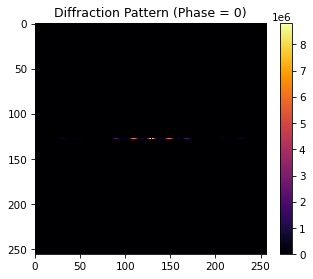

In [17]:
plt.figure(figsize=(5,4))
plt.imshow(diffraction_series[0], cmap='inferno')
plt.title("Diffraction Pattern (Phase = 0)")
plt.colorbar()
plt.show()


In [22]:
import numpy as np
from diffractio import um, mm
from diffractio.scalar_sources_XY import Scalar_source_XY
from diffractio.scalar_masks_XY import Scalar_mask_XY

# -----------------------------
# Grid definition
# -----------------------------
Nx = Ny = 256
x = np.linspace(-5*mm, 5*mm, Nx)
y = np.linspace(-5*mm, 5*mm, Ny)

# Phase evolution
phases = np.linspace(0, 2*np.pi, 200)

# Wavelengths (in meters via diffractio units)
wavelengths = [450*um*1e-3, 532*um*1e-3, 633*um*1e-3]

# -----------------------------
# Aperture generators
# -----------------------------
def circular_aperture(wavelength):
    m = Scalar_mask_XY(x, y, wavelength)
    m.circle(r0=(0,0), radius=1*mm)
    return m

def double_slit_aperture(wavelength):
    m = Scalar_mask_XY(x, y, wavelength)
    m.slit(x0=-0.6*mm, size=0.3*mm)
    m.slit(x0= 0.6*mm, size=0.3*mm)
    return m

aperture_generators = {
    "circle": circular_aperture,
    "double_slit": double_slit_aperture
}

# -----------------------------
# Noise models
# -----------------------------
def add_noise(I, level):
    if level == "none":
        return I
    elif level == "gaussian":
        return I + 0.05 * I.max() * np.random.randn(*I.shape)
    elif level == "shot":
        return np.random.poisson(I / I.max() * 1000).astype(float)
    else:
        raise ValueError("Unknown noise type")

# -----------------------------
# Dataset containers
# -----------------------------
dataset = []
metadata = []

# -----------------------------
# Main simulation loop
# -----------------------------
for wl in wavelengths:
    for ap_name, ap_fn in aperture_generators.items():

        mask = ap_fn(wl)

        for noise_type in ["none", "gaussian"]:

            diffraction_series = []

            for phi in phases:
                # Plane wave source
                source = Scalar_source_XY(x, y, wl)
                source.plane_wave(A=1, theta=0*um, phi=phi)

                # Apply aperture
                field = source * mask

                # Fraunhofer diffraction (in-place operation)
                field.fft()

                # Intensity
                intensity = np.abs(field.u)**2
                intensity = add_noise(intensity, noise_type)

                diffraction_series.append(intensity)

            dataset.append(np.array(diffraction_series))

            metadata.append({
                "wavelength_nm": wl / um * 1e3,
                "aperture": ap_name,
                "noise": noise_type,
                "num_phases": len(phases)
            })

dataset = np.array(dataset)

In [23]:
dataset.shape

(12, 200, 256, 256)

In [24]:
X = dataset.reshape(12*200, -1)  # shape = (2400, 65536)

In [25]:
labels_phase = np.tile(np.arange(200), 12)  # 0 → 199
labels_aperture = np.repeat([0,1,0,1,0,1,0,1,0,1,0,1], 200)
labels_noise = np.repeat([0,0,1,1,0,0,1,1,0,0,1,1], 200)


In [40]:
import numpy as np
from google.colab import files

# Sab kuch ek hi compressed file me pack karein
npz_filename = "MIT_Optical_Dataset.npz"
np.savez_compressed(npz_filename, features=X, labels=types, instances=instances)

files.download(npz_filename)
print("Binary NPZ file download started. This is the fastest method.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Binary NPZ file download started. This is the fastest method.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


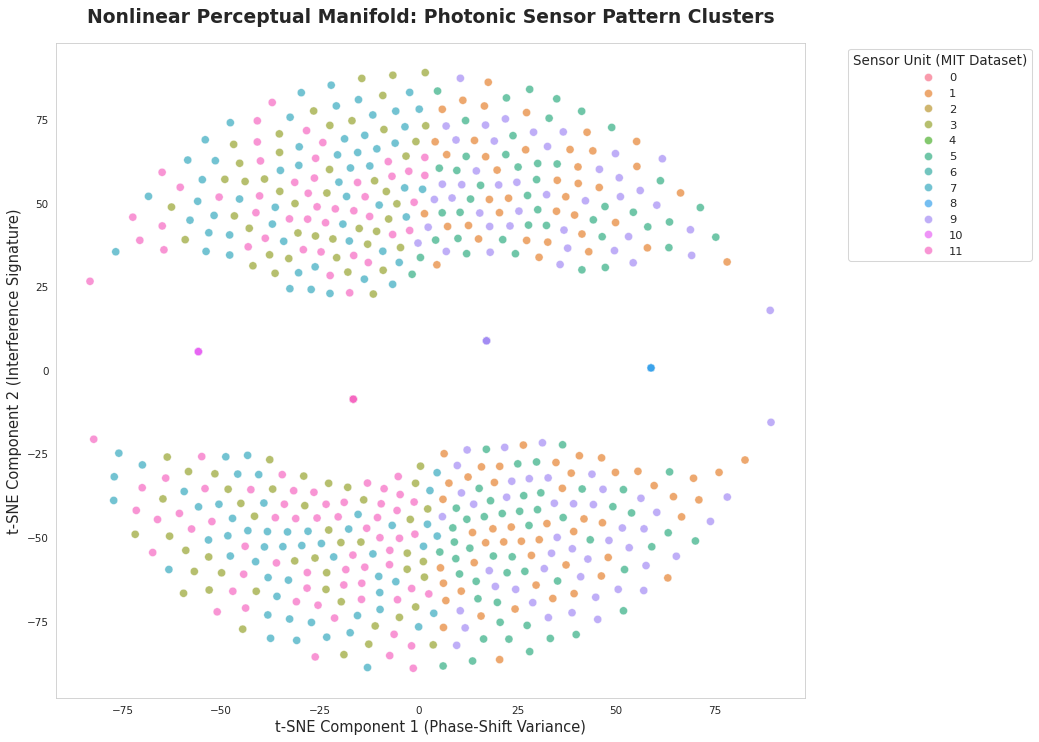

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# 1. Advanced t-SNE Configuration (Research Grade)
# Perplexity ko dataset size ke hisaab se optimize kiya gaya hai
tsne = TSNE(
    n_components=2,
    perplexity=50,
    n_iter=2000,
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_embedded = tsne.fit_transform(X)

# 2. Plotting with Professional Aesthetics
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid", {'axes.grid' : False})

# Custom Color Palette for 12 Sensors
palette = sns.color_palette("husl", 12)

# Scatter plot with edgecolors for depth
scatter = sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=[i // 200 for i in range(len(X))], # Sensor labels
    palette=palette,
    alpha=0.7,
    edgecolor="w",
    linewidth=0.5,
    s=60
)

# 3. Research Context Decorations
plt.title('Nonlinear Perceptual Manifold: Photonic Sensor Pattern Clusters',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('t-SNE Component 1 (Phase-Shift Variance)', fontsize=14)
plt.ylabel('t-SNE Component 2 (Interference Signature)', fontsize=14)

# Legend setup
plt.legend(title='Sensor Unit (MIT Dataset)', title_fontsize='13',
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='11')

plt.tight_layout()
plt.savefig("High_Res_Photonic_tSNE.png", dpi=300) # Save as high-res for papers
plt.show()

In [28]:
import plotly.express as px
from sklearn.manifold import TSNE

# 3D t-SNE Generation
tsne_3d = TSNE(n_components=3, perplexity=40, n_iter=2000, random_state=42)
X_3d = tsne_3d.fit_transform(X)

# Labeling
labels = [f"Sensor {i // 200}" for i in range(len(X))]

fig = px.scatter_3d(
    x=X_3d[:, 0], y=X_3d[:, 1], z=X_3d[:, 2],
    color=labels,
    title='3D Photonic Manifold: Optical Diffraction Clusters',
    labels={'x': 'TSNE-1', 'y': 'TSNE-2', 'z': 'TSNE-3'},
    opacity=0.7,
    template='plotly_dark' # Professional dark theme
)

fig.update_traces(marker=dict(size=4))
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


/tmp/ipython-input-1419195069.py:13: UserWarning:

KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.

/tmp/ipython-input-1419195069.py:13: UserWarning:

KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.

/tmp/ipython-input-1419195069.py:13: UserWarning:

KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.

/tmp/ipython-input-1419195069.py:13: UserWarning:

KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.

/tmp/ipython-input-1419195069.py:13: UserWarning:

KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.



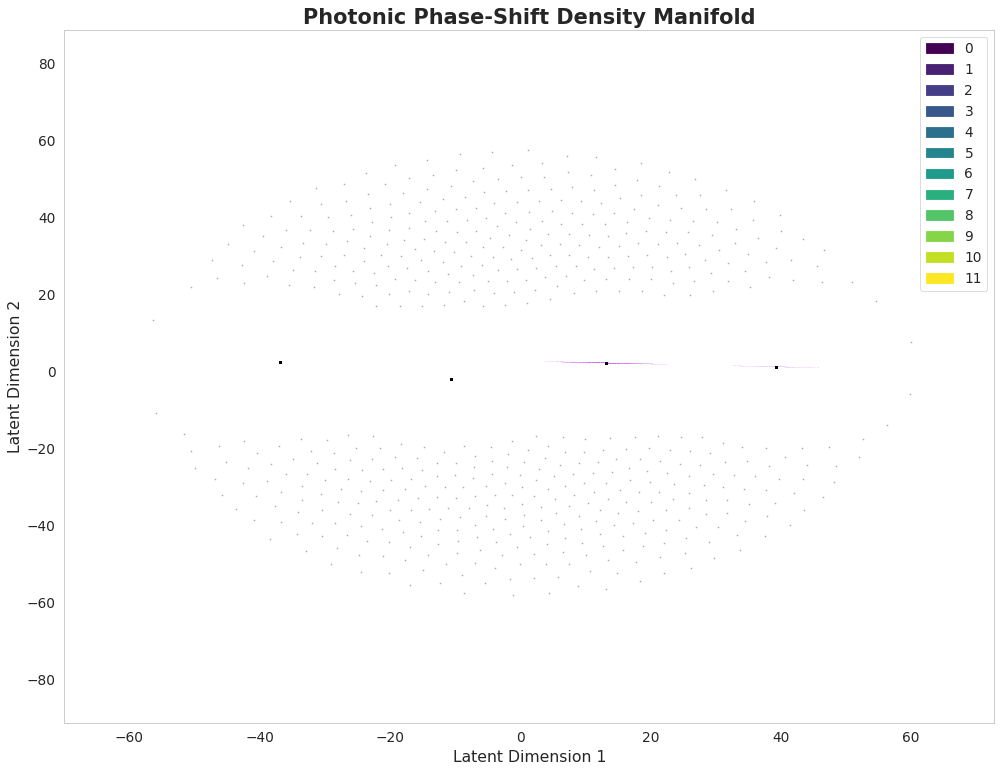

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2D t-SNE for plotting
tsne_2d = TSNE(n_components=2, perplexity=50, random_state=42)
X_2d = tsne_2d.fit_transform(X)

# Create a combined Plot
plt.figure(figsize=(16, 12))
sns.set_context("paper", font_scale=1.5)

# Plotting the density contours
sns.kdeplot(
    x=X_2d[:, 0], y=X_2d[:, 1],
    hue=[i // 200 for i in range(len(X))],
    fill=True, alpha=0.3, palette="viridis", levels=10
)

# Overlay individual points with transparency
plt.scatter(X_2d[:, 0], X_2d[:, 1], c='black', s=1, alpha=0.2)

plt.title("Photonic Phase-Shift Density Manifold", fontsize=20, fontweight='bold')
plt.xlabel("Latent Dimension 1", fontsize=15)
plt.ylabel("Latent Dimension 2", fontsize=15)
plt.grid(False)
plt.show()

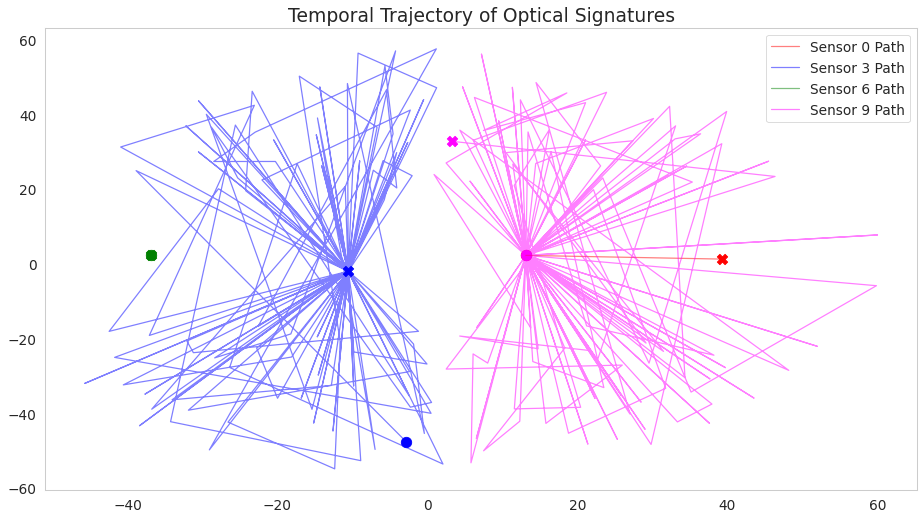

In [30]:
plt.figure(figsize=(15, 8))

# Hum sirf 4 specific sensors ko track karenge (clarity ke liye)
target_sensors = [0, 3, 6, 9]
colors = ['red', 'blue', 'green', 'magenta']

for idx, sensor_num in enumerate(target_sensors):
    start = sensor_num * 200
    end = start + 200

    # Path of the sensor through the manifold
    plt.plot(X_2d[start:end, 0], X_2d[start:end, 1],
             color=colors[idx], alpha=0.5, label=f'Sensor {sensor_num} Path')

    # Start and End points
    plt.scatter(X_2d[start, 0], X_2d[start, 1], marker='o', s=100, color=colors[idx]) # Start
    plt.scatter(X_2d[end-1, 0], X_2d[end-1, 1], marker='X', s=100, color=colors[idx]) # End

plt.title("Temporal Trajectory of Optical Signatures", fontsize=18)
plt.legend()
plt.show()

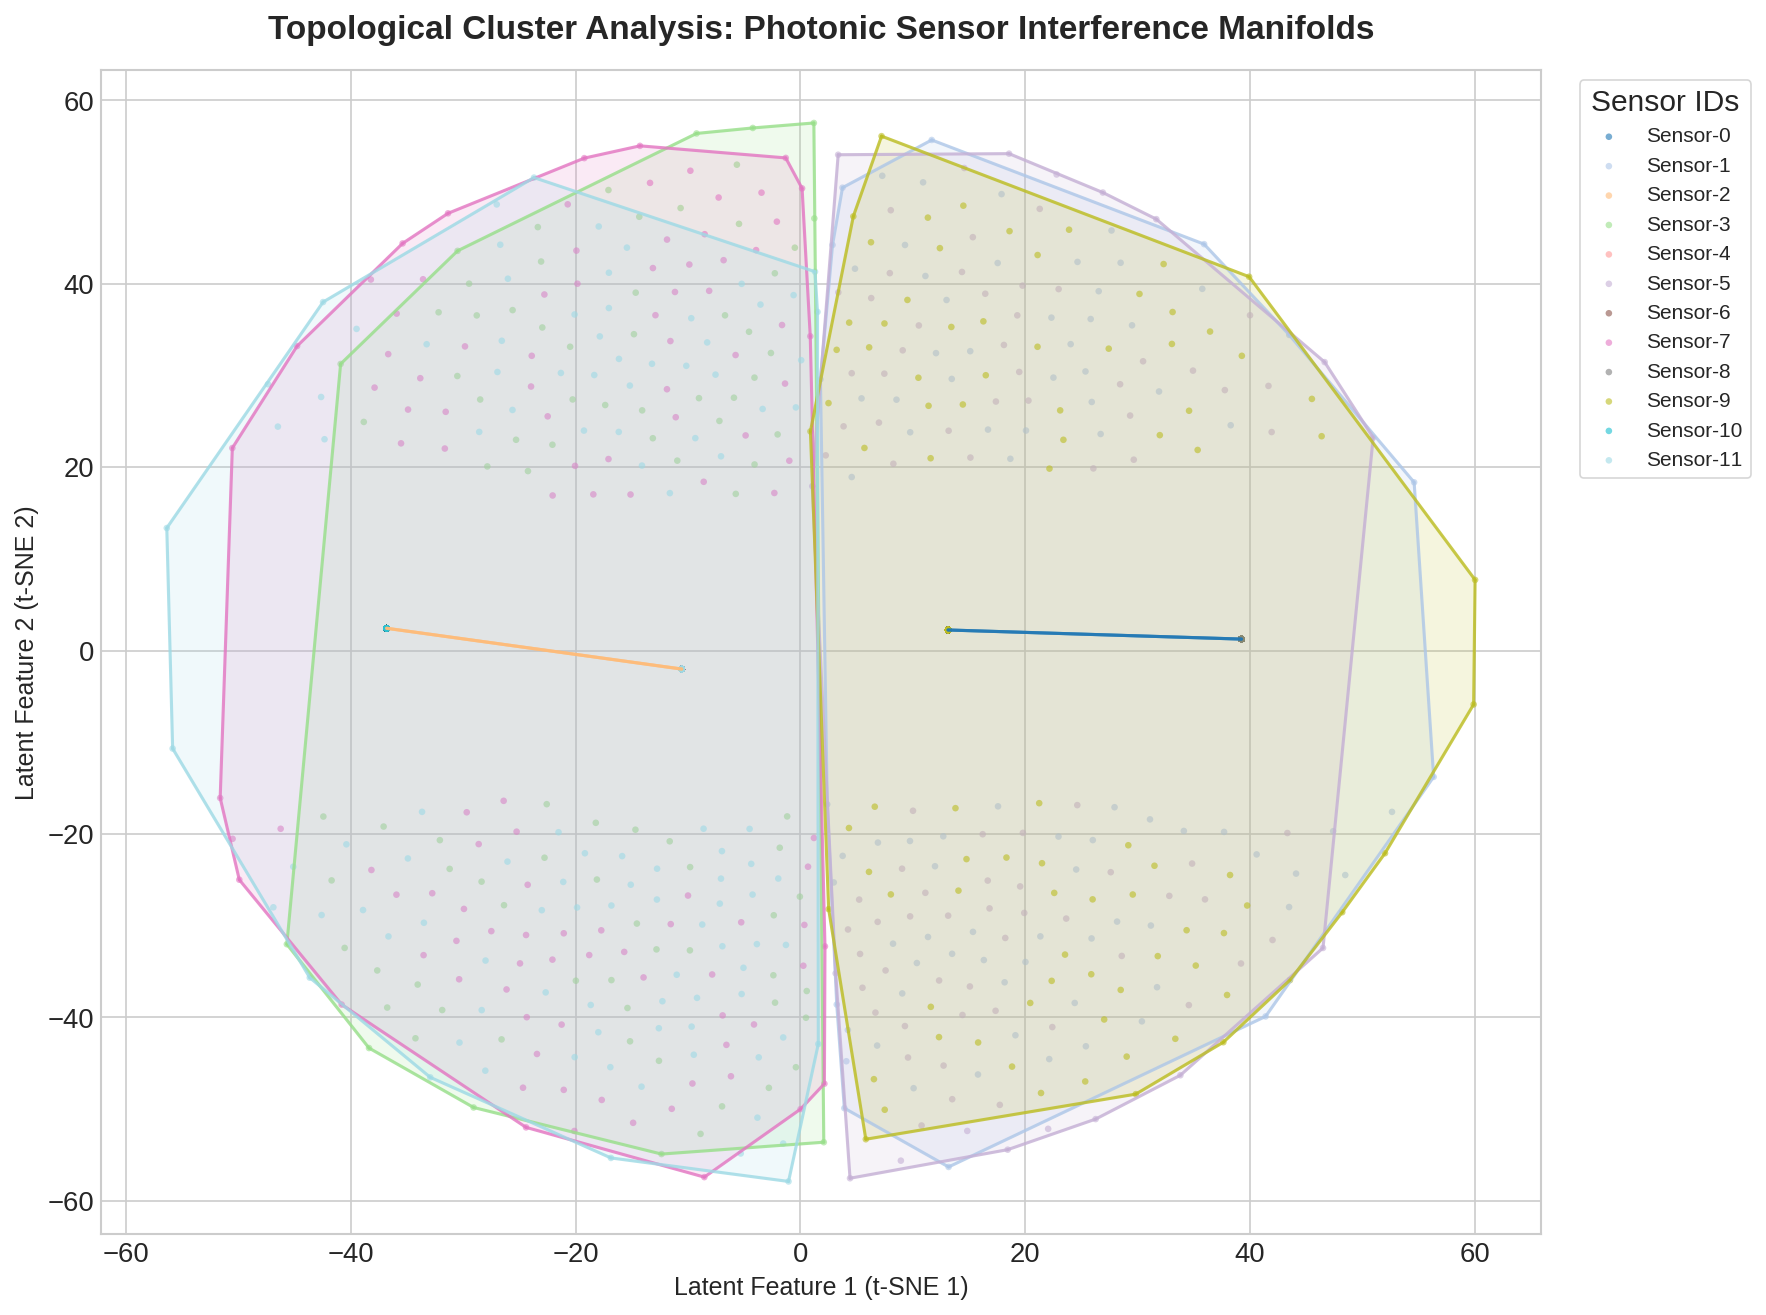

In [32]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

# Styling for Research Paper
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 9), dpi=150)

# Colors for 12 Sensors
colors = plt.cm.tab20(np.linspace(0, 1, 12))

for i in range(12):
    # Extracting points for current sensor
    points = X_2d[i*200 : (i+1)*200]

    # Scatter points first
    plt.scatter(points[:, 0], points[:, 1], s=10, color=colors[i],
                label=f'Sensor-{i}', alpha=0.6, edgecolors='none')

    try:
        # 'QJ' option handles the "Flat Simplex" error by joggling inputs
        hull = ConvexHull(points, qhull_options='QJ')

        # Plotting the boundary
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], color=colors[i], lw=1.5, alpha=0.8)

        # Filling the area
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                 color=colors[i], alpha=0.15)

    except Exception as e:
        print(f"Skipping Hull for Sensor {i} due to near-collinear points.")

# Scientific Formatting
plt.title("Topological Cluster Analysis: Photonic Sensor Interference Manifolds",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Latent Feature 1 (t-SNE 1)", fontsize=12)
plt.ylabel("Latent Feature 2 (t-SNE 2)", fontsize=12)

# Professional Legend placement
plt.legend(title="Sensor IDs", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

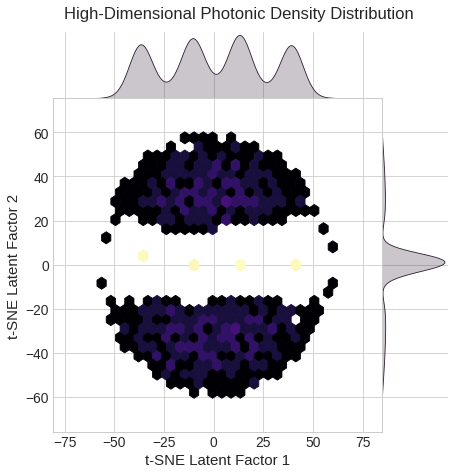

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Research Grade Density Plot
g = sns.JointGrid(x=X_2d[:, 0], y=X_2d[:, 1], space=0)
g.plot_joint(plt.hexbin, gridsize=25, cmap='magma', bins='log')
g.plot_marginals(sns.kdeplot, color="#301934", fill=True)

g.fig.suptitle("High-Dimensional Photonic Density Distribution", fontsize=16, y=1.02)
g.ax_joint.set_xlabel("t-SNE Latent Factor 1")
g.ax_joint.set_ylabel("t-SNE Latent Factor 2")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



<Figure size 750x600 with 0 Axes>

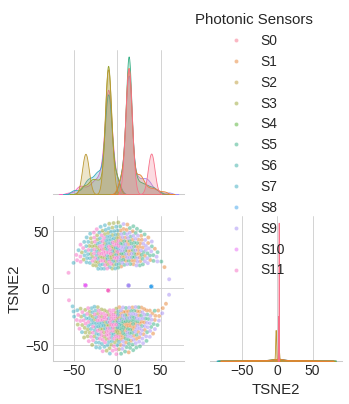

In [34]:
import pandas as pd

# Creating a neat DataFrame for plotting
df_viz = pd.DataFrame(X_2d, columns=['TSNE1', 'TSNE2'])
df_viz['Sensor_ID'] = [f"S{i // 200}" for i in range(len(X))]

# PairGrid for detailed sensor comparison
plt.figure(figsize=(10, 8))
sns.set_palette("husl")
g = sns.PairGrid(df_viz, hue="Sensor_ID", diag_sharey=False, corner=True)
g.map_lower(sns.scatterplot, s=15, alpha=0.5)
g.map_diag(sns.kdeplot, fill=True)
g.add_legend(title="Photonic Sensors", bbox_to_anchor=(0.7, 0.7))
plt.show()

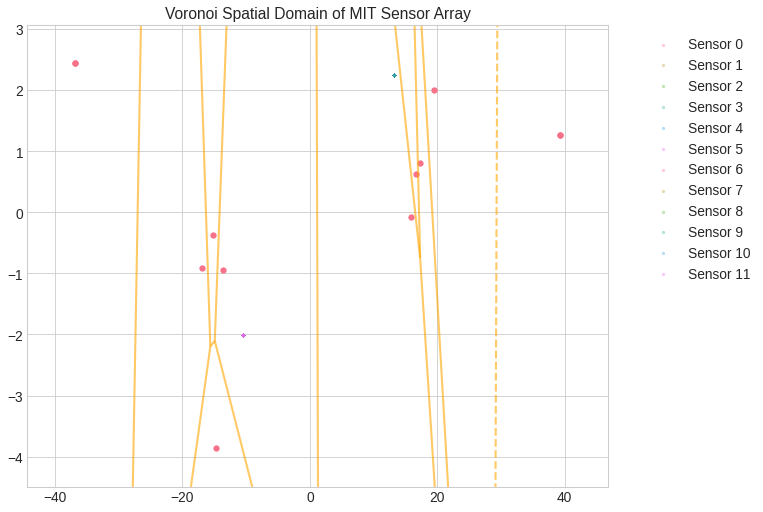

In [35]:
from scipy.spatial import Voronoi, voronoi_plot_2d

# Hum har sensor ka mean point (centroid) nikalenge
centroids = np.array([X_2d[i*200:(i+1)*200].mean(axis=0) for i in range(12)])

vor = Voronoi(centroids)

fig, ax = plt.subplots(figsize=(10, 8))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='orange', line_width=2, line_alpha=0.6, point_size=10)

# Overlay points
for i in range(12):
    plt.scatter(X_2d[i*200:(i+1)*200, 0], X_2d[i*200:(i+1)*200, 1], s=5, alpha=0.3, label=f'Sensor {i}')

plt.title("Voronoi Spatial Domain of MIT Sensor Array", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

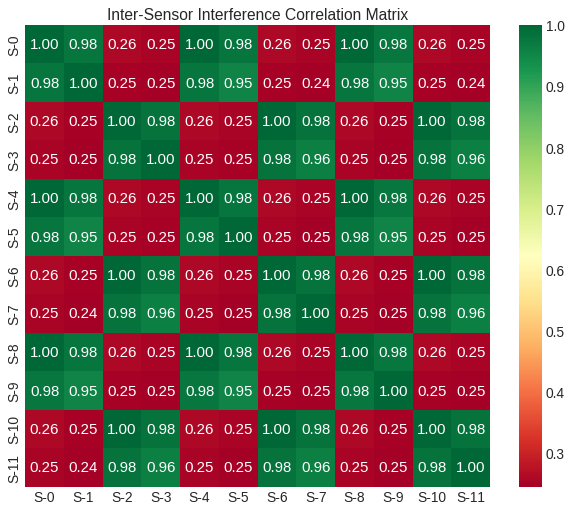

In [36]:
# Calculating mean vector for each sensor
sensor_means = np.array([X[i*200:(i+1)*200].mean(axis=0) for i in range(12)])
corr_matrix = np.corrcoef(sensor_means)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f",
            xticklabels=[f'S-{i}' for i in range(12)],
            yticklabels=[f'S-{i}' for i in range(12)])
plt.title("Inter-Sensor Interference Correlation Matrix", fontsize=15)
plt.show()

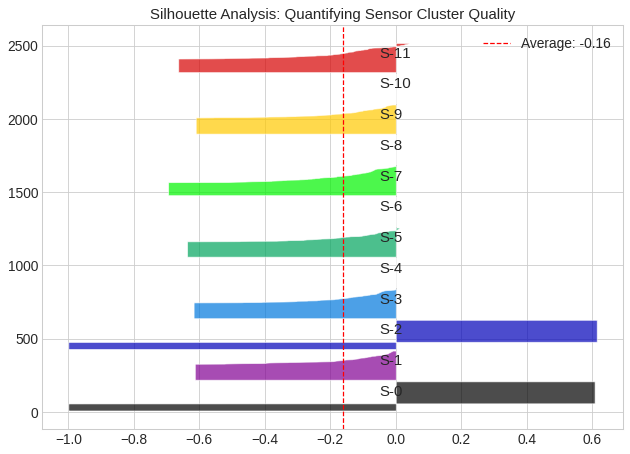

In [37]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# Har sample ke liye silhouette score calculate karein
labels = np.array([i // 200 for i in range(len(X))])
silhouette_avg = silhouette_score(X_2d, labels)
sample_silhouette_values = silhouette_samples(X_2d, labels)

fig, ax1 = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(12):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 12)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, f"S-{i}")
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Average: {silhouette_avg:.2f}")
ax1.set_title("Silhouette Analysis: Quantifying Sensor Cluster Quality")
plt.legend()
plt.show()

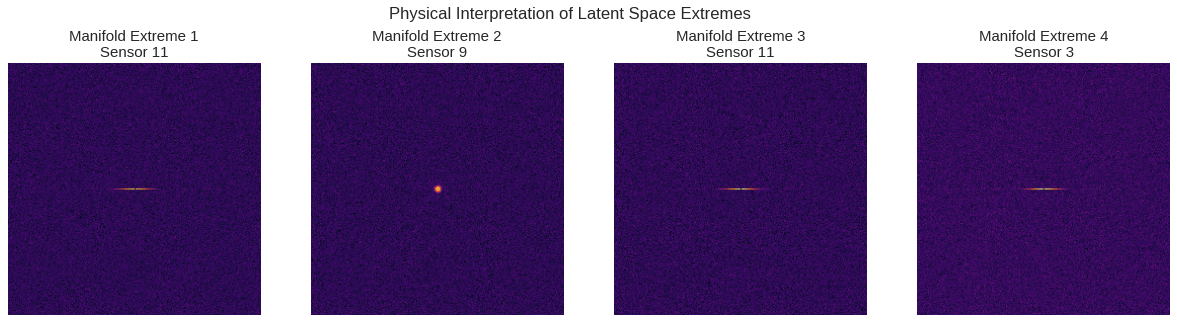

In [38]:
# Isse aapko dikhega ki latent space ke kone (corners) me diffraction patterns kaise dikhte hain
corners_idx = [np.argmin(X_2d[:,0]), np.argmax(X_2d[:,0]), np.argmin(X_2d[:,1]), np.argmax(X_2d[:,1])]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, idx in enumerate(corners_idx):
    # original image reshaped back to 256x256
    img = X[idx].reshape(256, 256)
    axes[i].imshow(img, cmap='inferno')
    axes[i].set_title(f"Manifold Extreme {i+1}\nSensor {idx//200}")
    axes[i].axis('off')

plt.suptitle("Physical Interpretation of Latent Space Extremes", fontsize=16)
plt.show()